# OCR for Devanagiri Digits

## Import libraries

In [1]:
# Normal ML data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Image manipulation
from skimage.io import imread
from skimage.transform import resize
import cv2

# ML Training and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix

## Preprocess Data

The preprocessing was taking extremely long on Google Colaboratory. So, the preprocessed data has been made available to it. If you wish to see how the preprocessing was performed, take a look at the Jupyter Notebook named *******

### Training Data

In [2]:
df_train = pd.read_csv('/content/drive/MyDrive/Mini Project/Train.csv')
df_train.shape

(17000, 1025)

In [3]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023,Target
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
x_train = df_train.drop(columns='Target')
y_train = df_train['Target']

### Testing Data

In [5]:
df_test = pd.read_csv('/content/drive/MyDrive/Mini Project/Test.csv')
df_test.shape

(3000, 1025)

In [6]:
x_test = df_test.drop(columns='Target')
y_test = df_test['Target']

## Model Training

In [7]:
numModel = svm.SVC()
numModel.fit(x_train,y_train)

SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [8]:
numPrd = numModel.predict(x_test)

Text(0.5, 1.0, 'Confusion Matrix of the New Model')

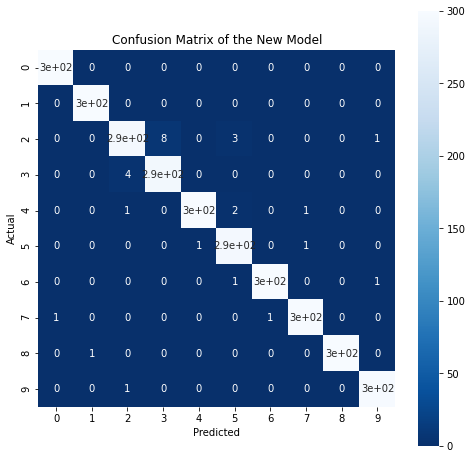

In [9]:
plt.figure(figsize=(8,8))
sns.heatmap(confusion_matrix(numPrd,y_test), annot=True, square = True, cmap='Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');
plt.title('Confusion Matrix of the New Model')

In [10]:
print(classification_report(numPrd,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00       299
           2       0.98      0.96      0.97       306
           3       0.97      0.99      0.98       296
           4       1.00      0.99      0.99       303
           5       0.98      0.99      0.99       296
           6       1.00      0.99      1.00       301
           7       0.99      0.99      0.99       300
           8       1.00      1.00      1.00       301
           9       0.99      1.00      0.99       299

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



### Hyperparameter Testing

In [11]:
from datetime import datetime

bfre = datetime.now()
current_time = bfre.strftime("%H:%M:%S")
print("Time before grid search: ", current_time)

model = svm.SVC(kernel='rbf')
max = 5
min = 3
step = 1

param = {
    'kernel':['linear','rbf'],
    'C': np.array(range(min,max,step)),
}

grid = GridSearchCV(model, param, n_jobs= 10,verbose=2)
grid.fit(x_train,y_train)

aftr = datetime.now()
current_time = aftr.strftime("%H:%M:%S")
print("Time after grid search: ", current_time)

grid.best_params_

Time before grid search:  18:22:27
Fitting 5 folds for each of 4 candidates, totalling 20 fits


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  12 out of  20 | elapsed:  9.6min remaining:  6.4min
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed: 12.4min finished


Time after grid search:  18:36:17


{'C': 4, 'kernel': 'rbf'}

After multiple grid searches done in batches, we arrive at the conclusion that C: 4 and kernel: 'rbf' are among the best parameters for our model.

In [12]:
gridPrd = grid.predict(x_test)

Text(0.5, 1.0, 'Confusion Matrix of the Tuned Model')

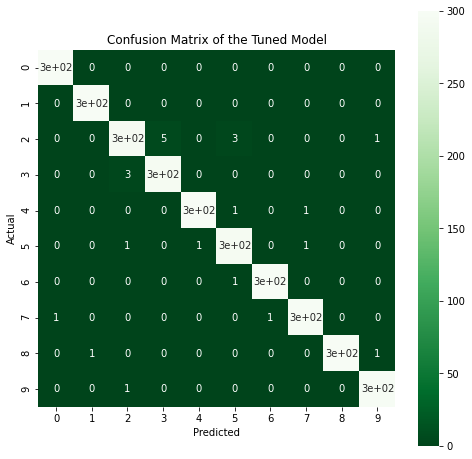

In [13]:
plt.figure(figsize=(8,8))
sns.heatmap(confusion_matrix(gridPrd,y_test), annot=True, square = True, cmap='Greens_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');
plt.title('Confusion Matrix of the Tuned Model')

In [14]:
print(classification_report(gridPrd,y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00       299
           2       0.98      0.97      0.98       304
           3       0.98      0.99      0.99       298
           4       1.00      0.99      1.00       301
           5       0.98      0.99      0.99       298
           6       1.00      1.00      1.00       300
           7       0.99      0.99      0.99       300
           8       1.00      0.99      1.00       302
           9       0.99      1.00      0.99       299

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000

